In [1]:
import cv2
import os
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from tqdm import tqdm

In [2]:
_path = 'Intel_Image'

In [3]:
_labels = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

In [4]:
IMGSIZE = (128, 128)
CNAMES = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
X_tr, y_tr, X_ts, y_ts = [], [], [], []
for label in _labels:
    path = _path + '/seg_train/seg_train/' + label
    #print(path)
    for f in sorted([_ for _ in os.listdir(path) if _.lower().endswith('.jpg')]):
        X_tr += [cv2.resize(cv2.imread(os.path.join(path,f)), IMGSIZE)]
        y_tr += [CNAMES.index(label)]

In [5]:
for label in _labels:
    path = _path + '/seg_test/seg_test/' + label
    #print(path)
    for f in sorted([_ for _ in os.listdir(path) if _.lower().endswith('.jpg')]):
        X_ts += [cv2.resize(cv2.imread(os.path.join(path,f)), IMGSIZE)]
        y_ts += [CNAMES.index(label)]

In [6]:
len(y_tr)

14034

In [7]:
image = cv2.cvtColor(X_tr[0], cv2.COLOR_BGR2RGB)


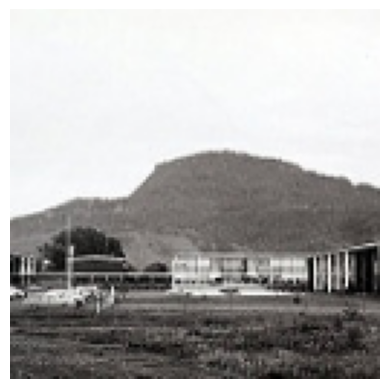

In [8]:
plt.imshow(image)
plt.axis('off')
plt.show()

In [9]:
image = cv2.cvtColor(X_tr[1], cv2.COLOR_BGR2RGB)


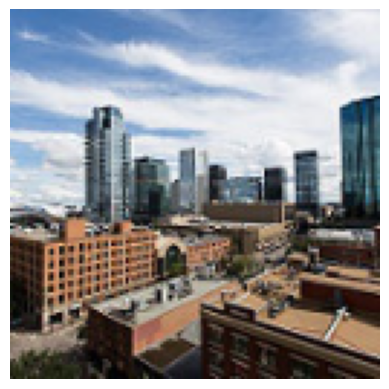

In [10]:
plt.imshow(image)
plt.axis('off')
plt.show()

In [11]:
image = cv2.cvtColor(X_tr[2], cv2.COLOR_BGR2RGB)


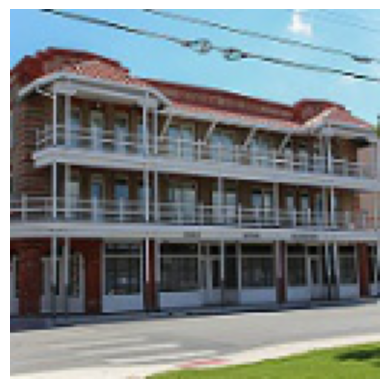

In [12]:
plt.imshow(image)
plt.axis('off')
plt.show()

In [13]:
X_tr = np.array(X_tr)
X_ts = np.array(X_ts)

In [14]:
X_tr = X_tr/255.0
X_ts = X_ts/255.0

In [15]:
#import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim

class CustomMLP(nn.Module):
    """ A PyTorch neural network model """
    def __init__(self, n_hidden=50, epochs=100, eta=0.1, minibatch_size=50, n_input=49152, n_output = 6):
        super().__init__()
        self.n_hidden = n_hidden  # hidden layer size
        self.epochs = epochs  # number of learning iterations
        self.eta = eta  # learning rate
        self.minibatch_size = minibatch_size  # size of training batch - 1 would not work
        #self.fc1, self.fc2, self.fc3 = None, None, None
        self.fc1 = nn.Linear(n_input, n_hidden)
        self.fc2 = nn.Linear(n_hidden, n_hidden)
        self.fc3 = nn.Linear(n_hidden, n_output)
        
    def _forward(self, X, apply_softmax=False):
        assert self.fc1 != None
        X = torch.flatten(X, start_dim=1)
        #print(X.shape)
        X = nn.functional.relu(self.fc1(X))
        X = nn.functional.relu(self.fc2(X))
        X = self.fc3(X)
        if apply_softmax:
            X = nn.functional.softmax(X, dim=1)
        return X

    def _reset(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                 m.reset_parameters()

    def predict(self, _X):
        assert self.fc1 is not None
        net_out = self._forward(_X, apply_softmax=True)
        p_values, indices = net_out.max(dim=1)
        return indices

    def fit(self, X_train, y_train):
        self._reset()  # Reset the neural network weights
        n_output= np.unique(y_train).shape[0]  # number of class labels
        n_features= X_train.shape[1]
        #print(X_train.shape)
        
        #self.fc1 = nn.Linear(n_features, self.n_hidden)  # A simple input layer
        #self.fc2 = nn.Linear(self.n_hidden, self.n_hidden)  # A simple hidden layer
        #self.fc3 = nn.Linear(self.n_hidden, n_output)  # A simple output layer
        
        optimizer = optim.SGD(self.parameters(), lr=self.eta, momentum=0.9)
        loss_func = nn.CrossEntropyLoss()

        for _ in tqdm(range(self.epochs)):
            indices = np.arange(X_train.shape[0])
            
            for start_idx in range(0, indices.shape[0] - self.minibatch_size + 1, self.minibatch_size):
                batch_idx = indices[start_idx:start_idx + self.minibatch_size]
                optimizer.zero_grad()
                
                net_out = self._forward(X_train[batch_idx])
                
                loss = loss_func(net_out, y_train[batch_idx])
                loss.backward()
                optimizer.step()

In [16]:
X_tr = torch.tensor(X_tr, dtype=torch.float32)
y_tr = torch.tensor(y_tr, dtype=torch.long)
X_ts = torch.tensor(X_ts, dtype=torch.float32)
y_ts = torch.tensor(y_ts, dtype=torch.long)

In [17]:
perm = torch.randperm(X_tr.shape[0])
X_tr = X_tr[perm]
y_tr = y_tr[perm]

In [18]:
clf = CustomMLP(50, 100, 0.1, 50)


In [19]:
clf.fit(X_tr,y_tr)

100%|██████████| 100/100 [21:09<00:00, 12.70s/it]


In [20]:
ypred = clf.predict(X_ts)

In [21]:
from sklearn.metrics import accuracy_score

In [22]:
print(accuracy_score(y_ts, ypred))

0.17


To make the model perform better I would experiment with different number of layers, number of neurons per layer, and activation functions. Then I would try experiemeting learning rates and batch sizes by graphing them at different values and seeing which gives the best accuracy. I would also look into if it would be worth turning the images into grayscale to reduce the number of features and seeing if that helps the accuracy because in this scenario it doesn't seem like color should matter too much.